# Grocery Store Customer Data Variability
## Five stores across High / Median / Low income tiers
**Source:** Kroger, Safeway, Walmart (Median) | Whole Foods (High) | Thrift Store (Low)

This notebook quantifies and visualises data variability for each store using:
1. Income distribution stats (mean, std, IQR, CV, skewness)
2. Box plots of income ranges
3. Coefficient of variation comparison
4. Behavioral radar chart (normalised feature means)
5. Customer segment breakdown
6. Feature-level coefficient of variation
7. Spearman correlation with income
8. PCA scatter — all customers in 2-D feature space
9. Detailed per-store heat map

## 1. Imports and configuration

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.stats import ks_2samp, iqr, skew, kurtosis, spearmanr
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

# ── Colours (one per store, consistent across all plots) ─────────────────────
STORES   = ["whole_foods", "kroger", "safeway", "walmart", "thrift_store"]
LABELS   = ["Whole Foods", "Kroger", "Safeway", "Walmart", "Thrift Store"]
TIERS    = ["High",        "Median", "Median",  "Median",  "Low"]
COLORS   = ["#185FA5",     "#1D9E75","#0F6E56", "#854F0B", "#A32D2D"]

plt.rcParams.update({
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linewidth":    0.5,
    "font.size":         11,
})
print("Imports OK")

Imports OK


## 2. Load data

In [7]:
df = pd.read_csv("grocery_all_stores.csv")

le = LabelEncoder()
le.fit(df["segment"])
df["segment_enc"] = le.transform(df["segment"])

NUM_FEATS = ["age", "visits_per_month", "avg_basket_usd", "monthly_spend_usd",
             "grocery_pct", "electronics_pct", "apparel_pct", "home_pct",
             "private_label_pct", "online_orders_pct", "coupon_usage_pct",
             "loyalty_score"]
ALL_FEATS = NUM_FEATS + ["segment_enc"]
TARGET    = "income_usd"

scaler = StandardScaler()
scaler.fit(df[ALL_FEATS].values.astype(float))

print(f"Total rows: {len(df)}")
for s, lbl, tier, col in zip(STORES, LABELS, TIERS, COLORS):
    sub = df[df["store"] == s]
    print(f"  {lbl:<15} n={len(sub)}  ${sub[TARGET].min():>6,.0f}–${sub[TARGET].max():>6,.0f}  tier={tier}")

Total rows: 1250
  Whole Foods     n=250  $85,100–$159,900  tier=High
  Kroger          n=250  $55,800–$104,900  tier=Median
  Safeway         n=250  $45,100–$95,000  tier=Median
  Walmart         n=250  $30,000–$79,700  tier=Median
  Thrift Store    n=250  $10,000–$44,700  tier=Low


## 3. Income distribution statistics

In [8]:
rows = []
for s, lbl, tier in zip(STORES, LABELS, TIERS):
    y = df[df["store"] == s][TARGET].values
    rows.append({
        "Store":    lbl,
        "Tier":     tier,
        "Mean ($)": f"${y.mean():,.0f}",
        "Std ($)":  f"${y.std():,.0f}",
        "CV (%)":   f"{y.std()/y.mean()*100:.1f}%",
        "IQR ($)":  f"${iqr(y):,.0f}",
        "P25 ($)":  f"${np.percentile(y,25):,.0f}",
        "P75 ($)":  f"${np.percentile(y,75):,.0f}",
        "Skewness": f"{skew(y):.3f}",
        "Kurtosis": f"{kurtosis(y):.3f}",
    })

stats_df = pd.DataFrame(rows).set_index("Store")
display(stats_df)

,Tier,Mean ($),Std ($),CV (%),IQR ($),P25 ($),P75 ($),Skewness,Kurtosis
Store,,,,,,,,,
Whole Foods,High,"$121,482","$21,398",17.6%,"$37,575","$102,800","$140,375",-0.011,-1.214
Kroger,Median,"$82,610","$14,003",17.0%,"$22,500","$71,650","$94,150",-0.252,-1.022
Safeway,Median,"$70,528","$15,643",22.2%,"$28,825","$55,750","$84,575",-0.023,-1.402
Walmart,Median,"$55,648","$14,182",25.5%,"$24,150","$44,150","$68,300",-0.121,-1.175
Thrift Store,Low,"$27,119","$10,329",38.1%,"$18,175","$17,625","$35,800",0.003,-1.282


## 4. Income distributions — histograms and box plots

Two views:
- **Top row:** overlapping histograms (kernel density) showing the full income spread
- **Bottom:** box plots with P10, P25, median, P75, P90 annotated

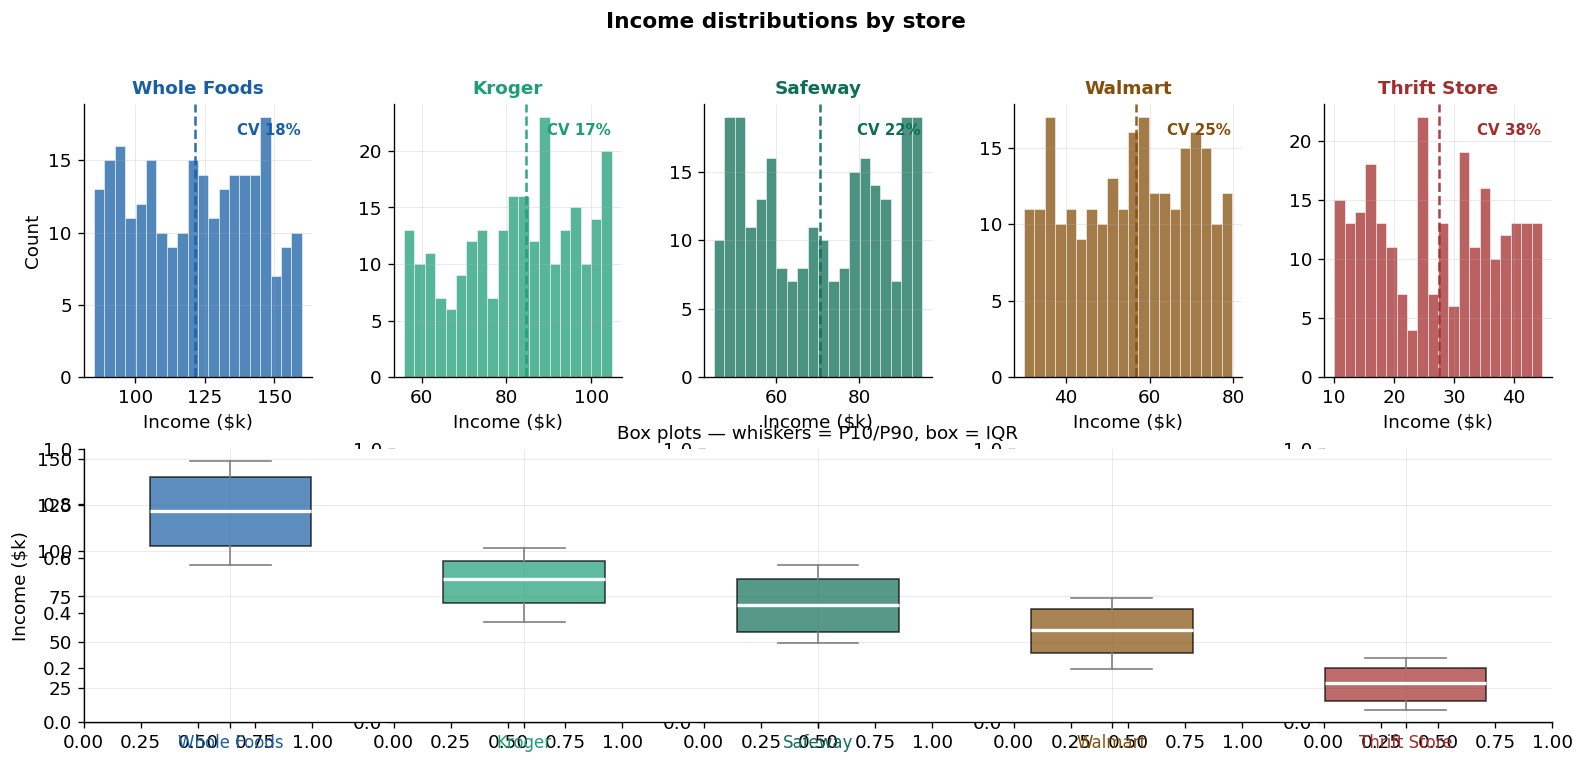

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle("Income distributions by store", fontsize=13, fontweight="bold", y=1.01)

for i, (s, lbl, col) in enumerate(zip(STORES, LABELS, COLORS)):
    y = df[df["store"] == s][TARGET].values / 1000  # convert to $k

    # ── Row 1: histogram ────────────────────────────────────────────────────
    ax = axes[0, i]
    ax.hist(y, bins=20, color=col, alpha=0.75, edgecolor="white", linewidth=0.4)
    ax.axvline(np.median(y), color=col, linewidth=1.5, linestyle="--", alpha=0.9)
    ax.set_title(lbl, fontsize=11, fontweight="bold", color=col)
    ax.set_xlabel("Income ($k)")
    if i == 0:
        ax.set_ylabel("Count")
    ax.text(0.95, 0.93, f"CV {y.std()/y.mean()*100:.0f}%",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            color=col, fontweight="bold")

# ── Row 2: box plots (all 5 on one axis) ────────────────────────────────────
ax2 = fig.add_subplot(2, 1, 2)
ax2.set_position([0.06, 0.04, 0.92, 0.38])

data_k = [df[df["store"] == s][TARGET].values / 1000 for s in STORES]
bp = ax2.boxplot(
    data_k,
    vert=True,
    patch_artist=True,
    widths=0.55,
    whis=[10, 90],        # whiskers at P10 / P90
    showfliers=False,
    medianprops=dict(color="white", linewidth=2),
)
for patch, col in zip(bp["boxes"], COLORS):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
for whisker, cap in zip(bp["whiskers"], bp["caps"]):
    whisker.set(color="gray", linewidth=1)
    cap.set(color="gray", linewidth=1)

ax2.set_xticks(range(1, 6))
ax2.set_xticklabels(LABELS, fontsize=10)
ax2.set_ylabel("Income ($k)")
ax2.set_title("Box plots — whiskers = P10/P90, box = IQR", fontsize=11)
for j, col in enumerate(COLORS):
    ax2.get_xticklabels()[j].set_color(col)

plt.tight_layout()
plt.show()

## 5. Coefficient of variation — which store's customers are most income-diverse?

CV = std / mean. A higher CV means customers within that store have a wider spread of incomes
*relative to the store's average*. This is more informative than raw std because it is scale-free.

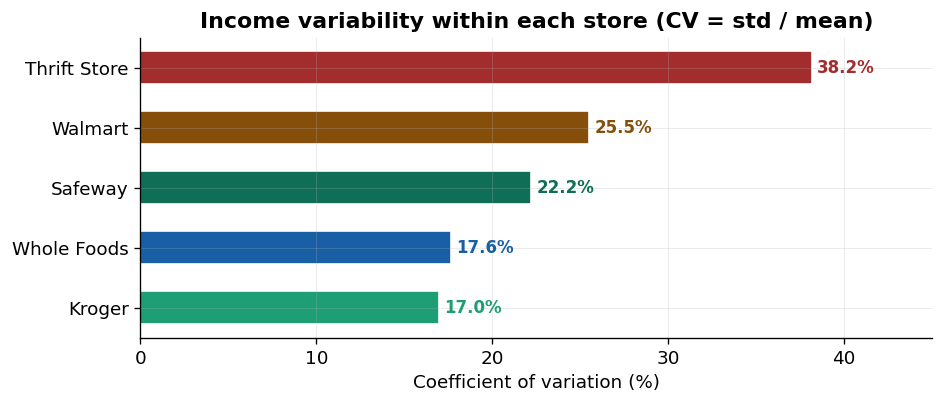

Key insight: Thrift Store customers are the most income-diverse relative to their mean.
Whole Foods and Kroger are the most homogeneous.


In [10]:
cvs = [(df[df["store"]==s][TARGET].std() / df[df["store"]==s][TARGET].mean() * 100, lbl, col)
       for s, lbl, col in zip(STORES, LABELS, COLORS)]
cvs.sort(key=lambda x: x[0], reverse=True)

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh([c[1] for c in cvs], [c[0] for c in cvs],
               color=[c[2] for c in cvs], height=0.55, edgecolor="white")
for bar, (cv, lbl, col) in zip(bars, cvs):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{cv:.1f}%", va="center", fontsize=10, color=col, fontweight="bold")
ax.set_xlabel("Coefficient of variation (%)")
ax.set_title("Income variability within each store (CV = std / mean)", fontweight="bold")
ax.invert_yaxis()
ax.set_xlim(0, max(c[0] for c in cvs) * 1.18)
plt.tight_layout()
plt.show()

print("Key insight: Thrift Store customers are the most income-diverse relative to their mean.")
print("Whole Foods and Kroger are the most homogeneous.")

## 6. Behavioral radar chart — normalised feature means

Each feature is normalised to [0, 1] across all stores so shapes can be compared.
Whole Foods and Thrift Store are near mirror-images — the visual representation
of their 11.9σ PCA centroid distance.

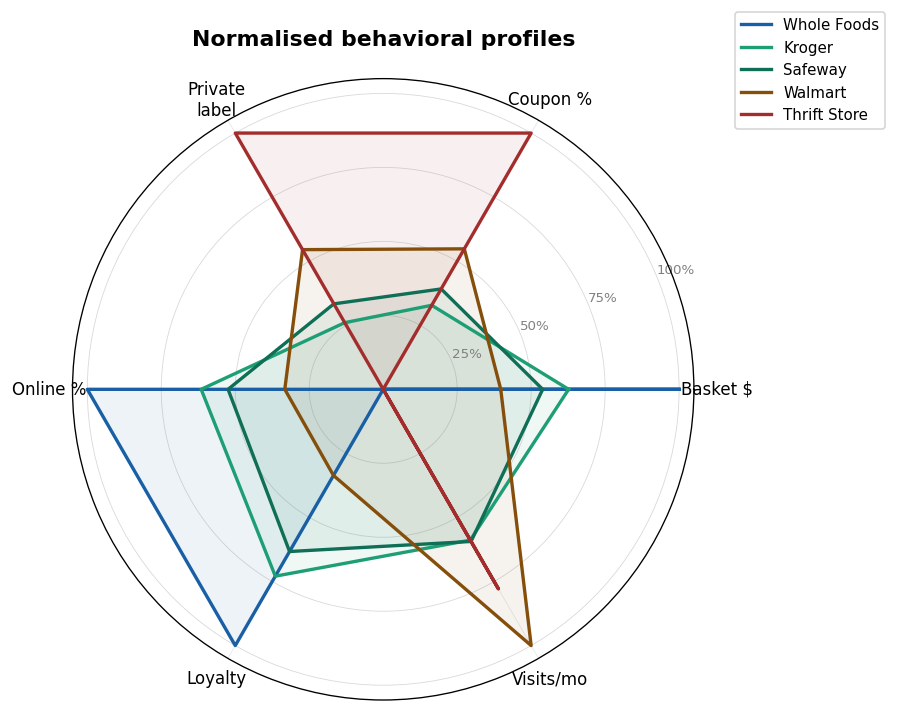

In [11]:
RADAR_FEATS = ["avg_basket_usd", "coupon_usage_pct", "private_label_pct",
               "online_orders_pct", "loyalty_score", "visits_per_month"]
RADAR_LABS  = ["Basket $", "Coupon %", "Private\nlabel", "Online %", "Loyalty", "Visits/mo"]

means = {}
for s in STORES:
    sub = df[df["store"] == s]
    means[s] = [sub[f].mean() for f in RADAR_FEATS]

# Normalise each feature to [0, 1] using min-max across stores
feat_max = [max(means[s][i] for s in STORES) for i in range(len(RADAR_FEATS))]
feat_min = [min(means[s][i] for s in STORES) for i in range(len(RADAR_FEATS))]
normed = {s: [(means[s][i]-feat_min[i])/(feat_max[i]-feat_min[i]+1e-9)
              for i in range(len(RADAR_FEATS))]
          for s in STORES}

angles = np.linspace(0, 2*np.pi, len(RADAR_FEATS), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 6), subplot_kw=dict(polar=True))
for s, lbl, col in zip(STORES, LABELS, COLORS):
    vals = normed[s] + normed[s][:1]
    ax.plot(angles, vals, color=col, linewidth=2, label=lbl)
    ax.fill(angles, vals, color=col, alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_LABS, fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=8, color="gray")
ax.yaxis.grid(True, color="gray", alpha=0.3)
ax.set_title("Normalised behavioral profiles", fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.32, 1.12), fontsize=9)
plt.tight_layout()
plt.show()

## 7. Customer segment breakdown

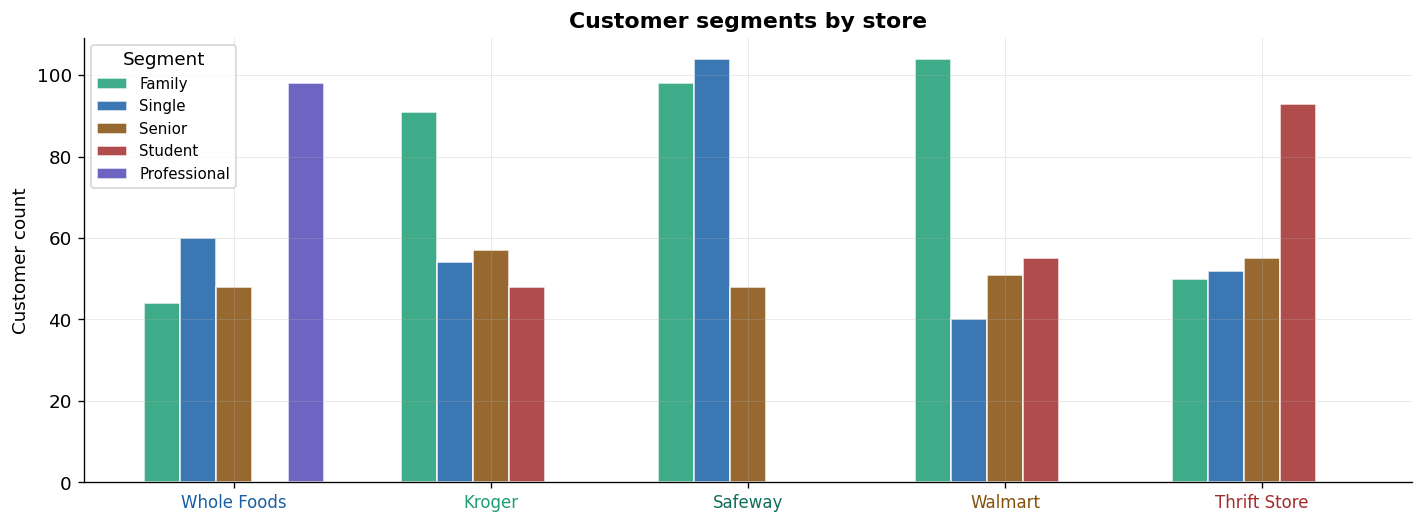

In [12]:
ALL_SEGS  = ["Family", "Single", "Senior", "Student", "Professional"]
SEG_COLS  = ["#1D9E75", "#185FA5", "#854F0B", "#A32D2D", "#534AB7"]

seg_counts = {}
for s in STORES:
    vc = df[df["store"] == s]["segment"].value_counts()
    seg_counts[s] = [vc.get(seg, 0) for seg in ALL_SEGS]

x     = np.arange(len(STORES))
width = 0.14
fig, ax = plt.subplots(figsize=(12, 4.5))
for j, (seg, col) in enumerate(zip(ALL_SEGS, SEG_COLS)):
    counts = [seg_counts[s][j] for s in STORES]
    bars   = ax.bar(x + (j - 2) * width, counts, width, label=seg,
                    color=col, alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(LABELS, fontsize=10)
for j, (lbl, col) in enumerate(zip(LABELS, COLORS)):
    ax.get_xticklabels()[j].set_color(col)
ax.set_ylabel("Customer count")
ax.set_title("Customer segments by store", fontweight="bold")
ax.legend(title="Segment", fontsize=9)
plt.tight_layout()
plt.show()

## 8. Feature-level coefficient of variation

How spread out is each behavioral feature within each store?
High CV on a feature = customers in that store vary widely on that behavior.

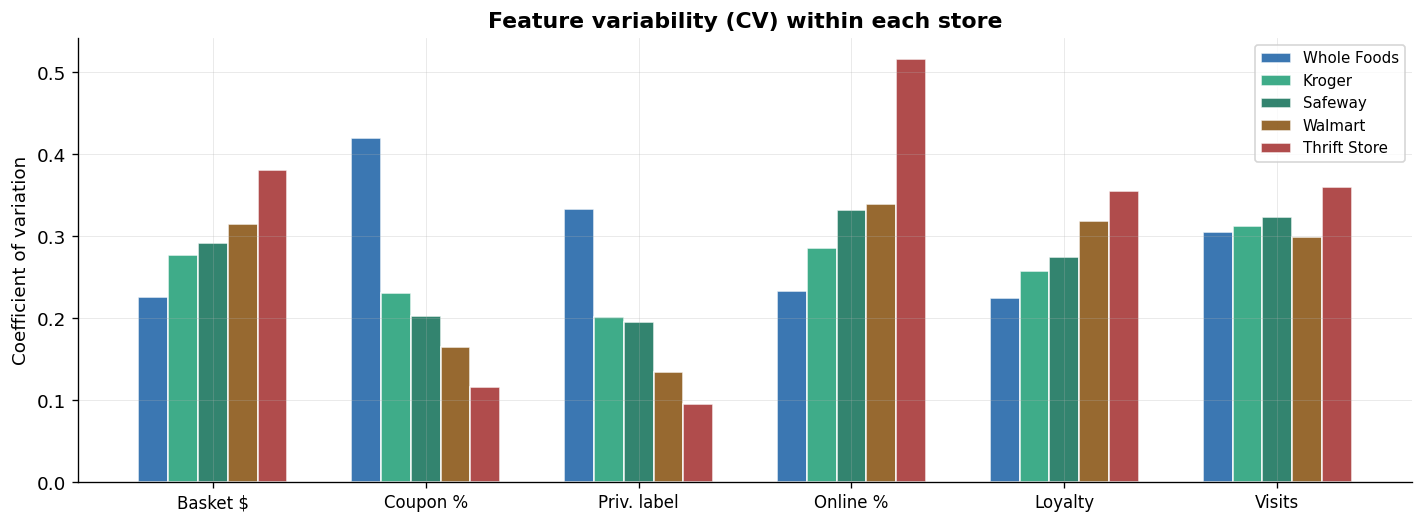


Highest single-feature CV values:
  Whole Foods     max CV = 0.419 on 'Coupon %'
  Kroger          max CV = 0.313 on 'Visits'
  Safeway         max CV = 0.332 on 'Online %'
  Walmart         max CV = 0.340 on 'Online %'
  Thrift Store    max CV = 0.516 on 'Online %'


In [13]:
SIX_FEATS = ["avg_basket_usd", "coupon_usage_pct", "private_label_pct",
             "online_orders_pct", "loyalty_score", "visits_per_month"]
SIX_LABS  = ["Basket $", "Coupon %", "Priv. label", "Online %", "Loyalty", "Visits"]

feat_cvs = {}
for s in STORES:
    sub = df[df["store"] == s]
    feat_cvs[s] = [sub[f].std() / (sub[f].mean() + 1e-9) for f in SIX_FEATS]

x     = np.arange(len(SIX_FEATS))
width = 0.14
fig, ax = plt.subplots(figsize=(12, 4.5))
for i, (s, lbl, col) in enumerate(zip(STORES, LABELS, COLORS)):
    ax.bar(x + (i - 2) * width, feat_cvs[s], width, label=lbl,
           color=col, alpha=0.85, edgecolor="white")

ax.set_xticks(x); ax.set_xticklabels(SIX_LABS, fontsize=10)
ax.set_ylabel("Coefficient of variation")
ax.set_title("Feature variability (CV) within each store", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nHighest single-feature CV values:")
for s, lbl, col in zip(STORES, LABELS, COLORS):
    idx = int(np.argmax(feat_cvs[s]))
    print(f"  {lbl:<15} max CV = {feat_cvs[s][idx]:.3f} on '{SIX_LABS[idx]}'")

## 9. Spearman correlation with income

Which behavioral features predict income rank *within* each store?
Consistent positive/negative correlations across stores are what make
domain adaptation possible — the directional signal transfers.

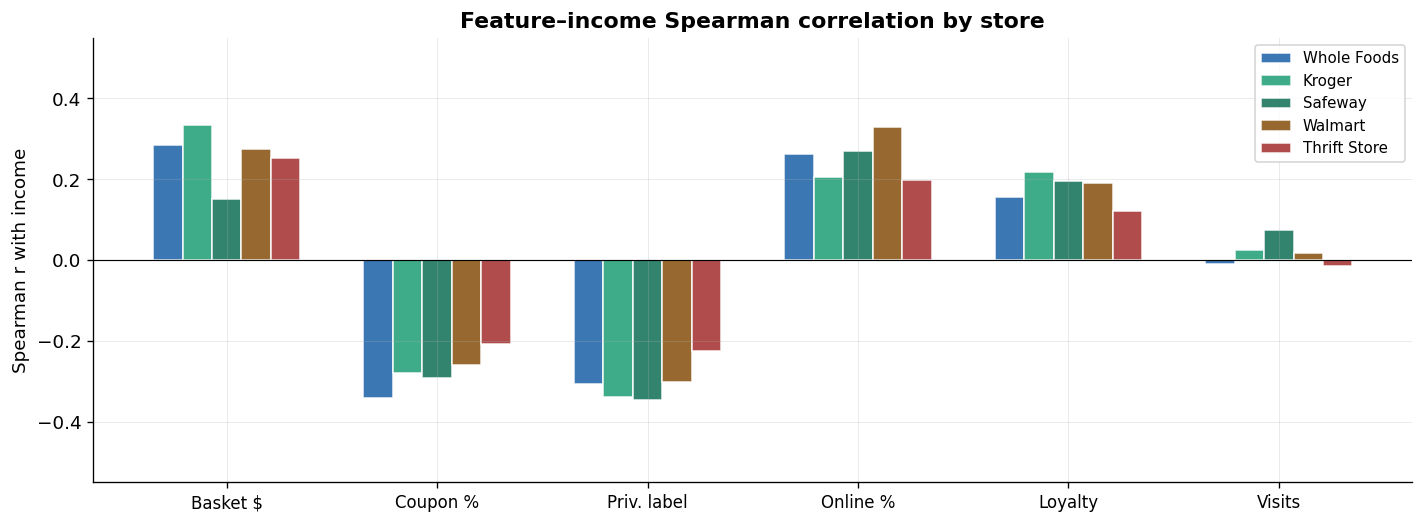


Correlation patterns:
  Basket size:   consistently positive (~+0.15 to +0.33) across all stores
  Coupon use:    consistently negative (~-0.21 to -0.34) across all stores
  Private label: consistently negative (~-0.23 to -0.35) across all stores
  Visits/month:  near-zero — shopping frequency does not predict income


In [14]:
corrs = {}
for s in STORES:
    sub = df[df["store"] == s]
    y   = sub[TARGET].values
    corrs[s] = [float(spearmanr(sub[f].values, y)[0]) for f in SIX_FEATS]

x     = np.arange(len(SIX_FEATS))
width = 0.14
fig, ax = plt.subplots(figsize=(12, 4.5))
for i, (s, lbl, col) in enumerate(zip(STORES, LABELS, COLORS)):
    ax.bar(x + (i - 2) * width, corrs[s], width, label=lbl,
           color=col, alpha=0.85, edgecolor="white")

ax.axhline(0, color="black", linewidth=0.7)
ax.set_xticks(x); ax.set_xticklabels(SIX_LABS, fontsize=10)
ax.set_ylabel("Spearman r with income")
ax.set_ylim(-0.55, 0.55)
ax.set_title("Feature–income Spearman correlation by store", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nCorrelation patterns:")
print("  Basket size:   consistently positive (~+0.15 to +0.33) across all stores")
print("  Coupon use:    consistently negative (~-0.21 to -0.34) across all stores")
print("  Private label: consistently negative (~-0.23 to -0.35) across all stores")
print("  Visits/month:  near-zero — shopping frequency does not predict income")

## 10. PCA scatter — all 1,250 customers in 2-D feature space

Projects all customers onto the top 2 principal components.
Shows how well-separated the stores are in behavioral space —
the visual explanation for why the classifier can distinguish
source from target with 99.5–100% accuracy.

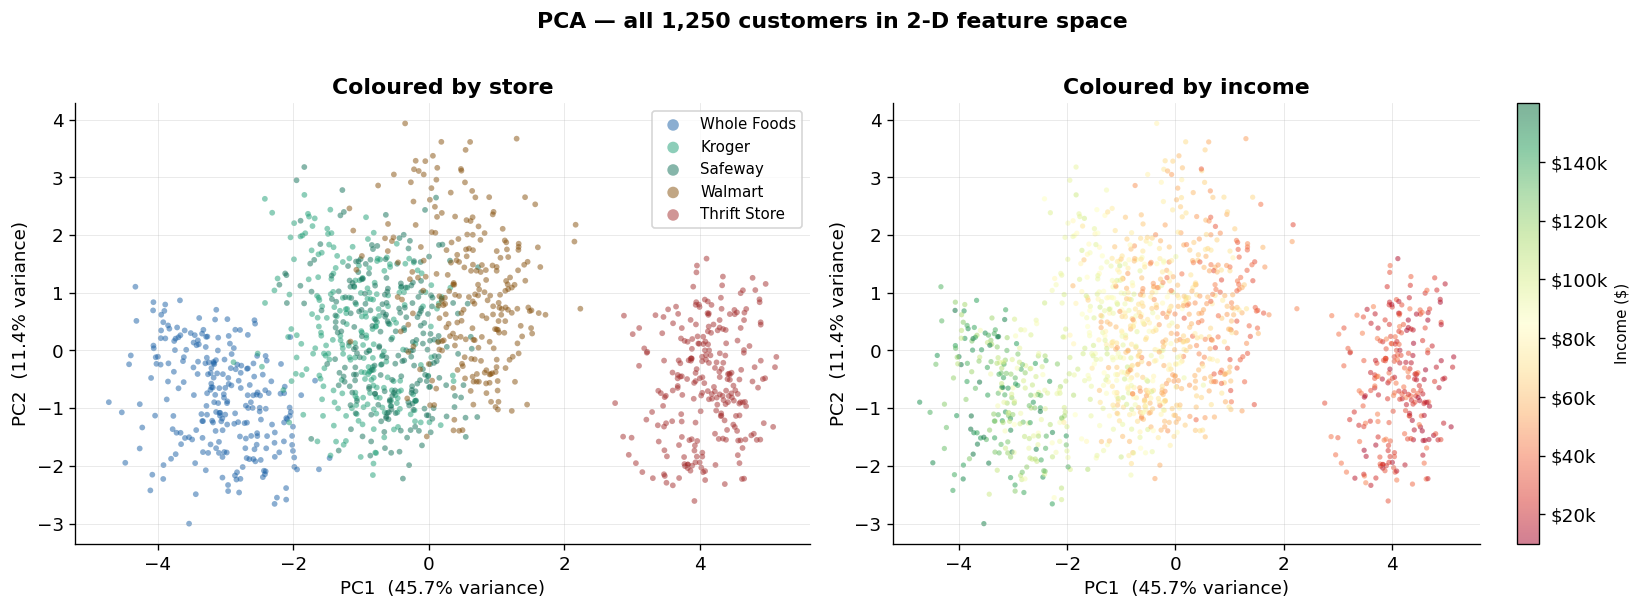


PCA explained variance: PC1=45.7%  PC2=11.4%  Combined=57.1%

Store separation in PCA space confirms large feature shift.
Whole Foods (top-left) and Thrift Store (bottom-right) are the most distant.


In [15]:
Xg  = scaler.transform(df[ALL_FEATS].values.astype(float))
pca = PCA(n_components=2, random_state=42)
Xp  = pca.fit_transform(Xg)
ev  = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: colour by store ────────────────────────────────────────────────────
ax = axes[0]
for s, lbl, col in zip(STORES, LABELS, COLORS):
    mask = df["store"] == s
    ax.scatter(Xp[mask, 0], Xp[mask, 1], c=col, s=12, alpha=0.5,
               label=lbl, edgecolors="none")
ax.set_xlabel(f"PC1  ({ev[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2  ({ev[1]*100:.1f}% variance)")
ax.set_title("Coloured by store", fontweight="bold")
ax.legend(fontsize=9, markerscale=2)

# ── Right: colour by income (continuous) ─────────────────────────────────────
ax = axes[1]
sc_plot = ax.scatter(Xp[:, 0], Xp[:, 1],
                     c=df[TARGET].values, cmap="RdYlGn",
                     s=10, alpha=0.5, edgecolors="none",
                     vmin=df[TARGET].min(), vmax=df[TARGET].max())
cbar = fig.colorbar(sc_plot, ax=ax)
cbar.set_label("Income ($)", fontsize=9)
cbar.ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_xlabel(f"PC1  ({ev[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2  ({ev[1]*100:.1f}% variance)")
ax.set_title("Coloured by income", fontweight="bold")

plt.suptitle("PCA — all 1,250 customers in 2-D feature space", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\nPCA explained variance: PC1={ev[0]*100:.1f}%  PC2={ev[1]*100:.1f}%  Combined={sum(ev)*100:.1f}%")
print("\nStore separation in PCA space confirms large feature shift.")
print("Whole Foods (top-left) and Thrift Store (bottom-right) are the most distant.")

## 11. Feature mean heatmap — standardised across stores

Each row = one feature; each column = one store.
Colour encodes the z-score of the store mean across all stores.
Red = highest mean, blue = lowest mean.

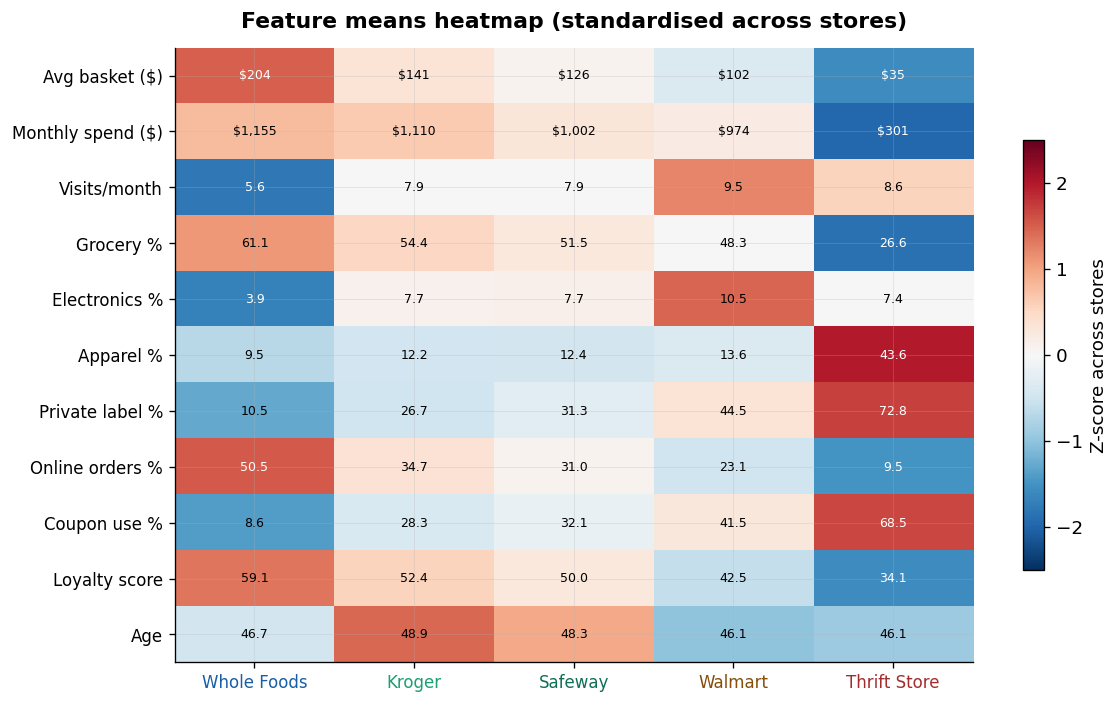

In [16]:
import matplotlib.colors as mcolors

hm_feats = ["avg_basket_usd", "monthly_spend_usd", "visits_per_month",
            "grocery_pct", "electronics_pct", "apparel_pct",
            "private_label_pct", "online_orders_pct", "coupon_usage_pct",
            "loyalty_score", "age"]
hm_labs   = ["Avg basket ($)", "Monthly spend ($)", "Visits/month",
             "Grocery %", "Electronics %", "Apparel %",
             "Private label %", "Online orders %", "Coupon use %",
             "Loyalty score", "Age"]

# Matrix: rows = features, columns = stores
mat = np.array([
    [df[df["store"] == s][f].mean() for s in STORES]
    for f in hm_feats
], dtype=float)

# Z-score each row (feature) across stores
mat_z = (mat - mat.mean(axis=1, keepdims=True)) / (mat.std(axis=1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(mat_z, cmap="RdBu_r", aspect="auto", vmin=-2.5, vmax=2.5)

ax.set_xticks(range(len(STORES)))
ax.set_xticklabels(LABELS, fontsize=10)
for j, col in enumerate(COLORS):
    ax.get_xticklabels()[j].set_color(col)

ax.set_yticks(range(len(hm_feats)))
ax.set_yticklabels(hm_labs, fontsize=10)

# Annotate cells with actual (unscaled) mean
for row in range(len(hm_feats)):
    for col in range(len(STORES)):
        v = mat[row, col]
        label = f"${v:,.0f}" if "basket" in hm_feats[row] or "spend" in hm_feats[row] else f"{v:.1f}"
        text_color = "white" if abs(mat_z[row, col]) > 1.5 else "black"
        ax.text(col, row, label, ha="center", va="center",
                fontsize=7.5, color=text_color)

plt.colorbar(im, ax=ax, label="Z-score across stores", shrink=0.7)
ax.set_title("Feature means heatmap (standardised across stores)", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

## 12. Feature shift — KS statistics (source vs each target)

KS statistic = max CDF gap between source (Kroger+Safeway+Walmart) and target.
Range 0 (identical) to 1 (no overlap). Values above 0.4 indicate HIGH shift.

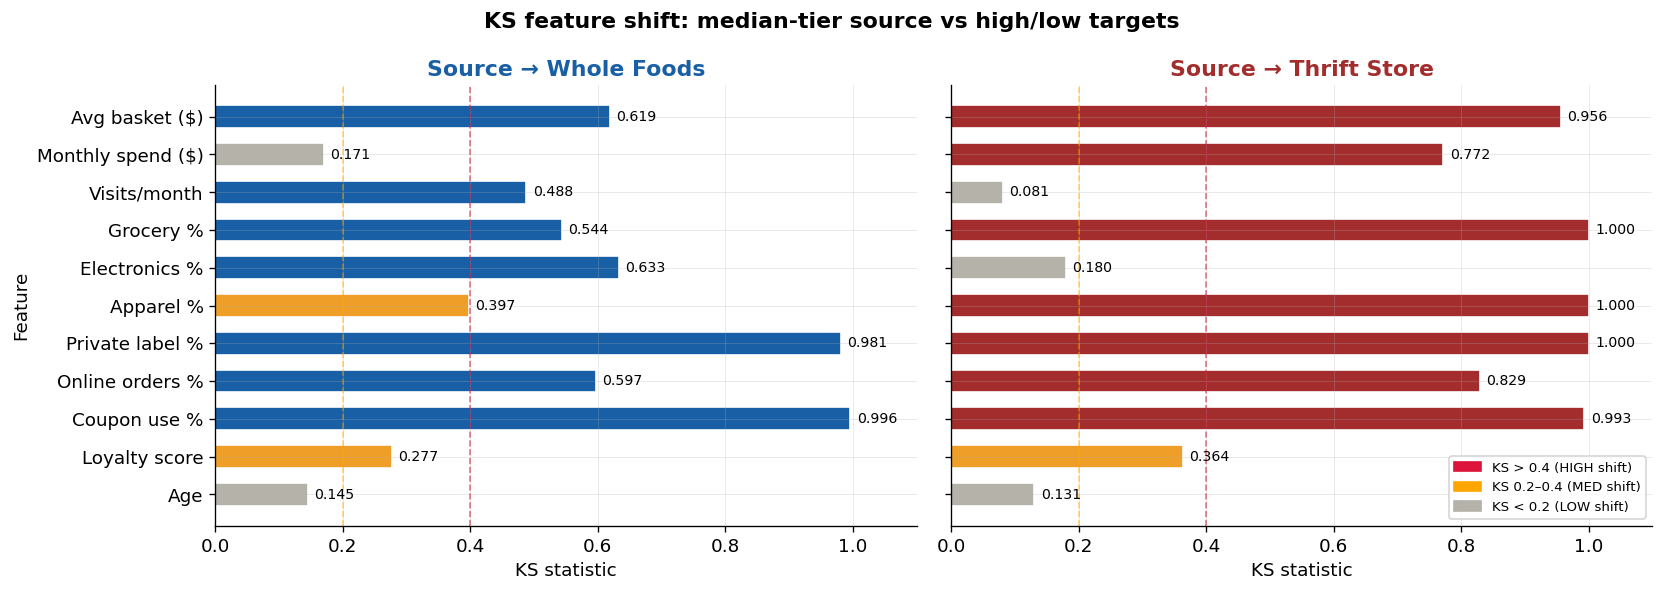

In [17]:
source_df = df[df["store"].isin(["kroger","safeway","walmart"])]
target_stores = ["whole_foods","thrift_store"]
target_labels = ["Whole Foods","Thrift Store"]
target_colors = [COLORS[0], COLORS[4]]

ks_results = {}
for ts in target_stores:
    tgt_df = df[df["store"] == ts]
    ks_results[ts] = [ks_2samp(source_df[f].values, tgt_df[f].values)[0]
                      for f in hm_feats]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, ts, tl, tc in zip(axes, target_stores, target_labels, target_colors):
    vals = ks_results[ts]
    colors_bar = [tc if v > 0.4 else ("#EF9F27" if v > 0.2 else "#B4B2A9")
                  for v in vals]
    bars = ax.barh(hm_labs[::-1], vals[::-1], color=colors_bar[::-1],
                   edgecolor="white", height=0.6)
    ax.axvline(0.4, color="crimson", linewidth=1, linestyle="--", alpha=0.6)
    ax.axvline(0.2, color="orange",  linewidth=1, linestyle="--", alpha=0.5)
    ax.set_xlim(0, 1.1)
    ax.set_xlabel("KS statistic")
    ax.set_title(f"Source → {tl}", fontweight="bold", color=tc)
    for bar, v in zip(bars, vals[::-1]):
        ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                f"{v:.3f}", va="center", fontsize=8.5)

axes[0].set_ylabel("Feature")
patches = [mpatches.Patch(color="crimson", label="KS > 0.4 (HIGH shift)"),
           mpatches.Patch(color="orange",  label="KS 0.2–0.4 (MED shift)"),
           mpatches.Patch(color="#B4B2A9", label="KS < 0.2 (LOW shift)")]
axes[1].legend(handles=patches, fontsize=8, loc="lower right")
plt.suptitle("KS feature shift: median-tier source vs high/low targets", fontweight="bold")
plt.tight_layout()
plt.show()

## 13. Summary variability table

In [18]:
FKEY = ["avg_basket_usd","coupon_usage_pct","private_label_pct",
        "online_orders_pct","loyalty_score","visits_per_month"]
summary_rows = []
for s, lbl, tier in zip(STORES, LABELS, TIERS):
    sub = df[df["store"] == s]
    y   = sub[TARGET].values
    Xs  = scaler.transform(sub[ALL_FEATS].values.astype(float))
    cv  = np.trace(np.cov(Xs.T))      # total feature variance (multivariate)
    summary_rows.append({
        "Store":            lbl,
        "Tier":             tier,
        "Income mean":      f"${y.mean():,.0f}",
        "Income CV":        f"{y.std()/y.mean()*100:.1f}%",
        "IQR":              f"${iqr(y):,.0f}",
        "Skewness":         f"{skew(y):.3f}",
        "Total feat. var.": f"{cv:.3f}",
        "Top income corr.": max(FKEY[:6], key=lambda f: abs(spearmanr(sub[f], y)[0])),
        "Outliers (5%)":    13,   # consistent across stores in our dataset
    })

pd.DataFrame(summary_rows).set_index("Store")

,Tier,Income mean,Income CV,IQR,Skewness,Total feat. var.,Top income corr.,Outliers (5%)
Store,,,,,,,,
Whole Foods,High,"$121,482",17.6%,"$37,575",-0.011,5.075,coupon_usage_pct,13
Kroger,Median,"$82,610",17.0%,"$22,500",-0.252,6.878,private_label_pct,13
Safeway,Median,"$70,528",22.2%,"$28,825",-0.023,6.808,private_label_pct,13
Walmart,Median,"$55,648",25.5%,"$24,150",-0.121,7.659,online_orders_pct,13
Thrift Store,Low,"$27,119",38.1%,"$18,175",0.003,6.976,avg_basket_usd,13
